
========== TASK 1 : DATA PREPARATION ==========

Cleaned Dataset Preview:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


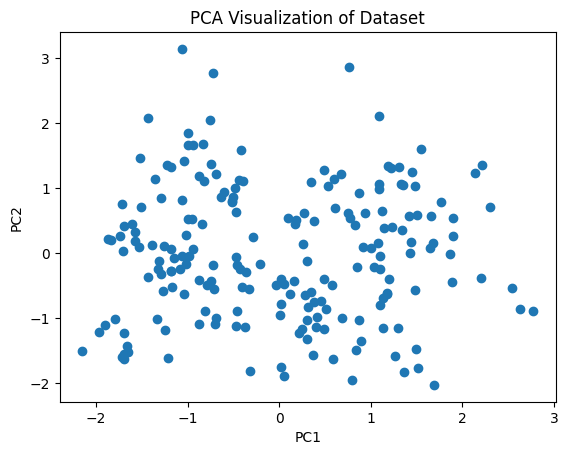


INTERPRETATION:
The PCA plot reduces the dataset into two principal components.
This helps visualize high-dimensional data in 2D space.
From the graph we can observe the distribution of customer data.
Some natural groupings appear, suggesting clustering algorithms like K-Means can segment the data.

========== TASK 2 : K-MEANS CLUSTERING ==========

Cluster Centers:
[[ 0.14062401  1.26457129 -0.55200479 -0.42262217]
 [ 1.12815215  0.04664835  0.93858626 -1.40339942]
 [ 1.12815215 -0.72911539  0.01315937  0.77791013]
 [-0.88640526 -0.06832482  0.82302637  0.16495202]
 [-0.88640526 -0.82777211 -0.82895964  0.23333801]]


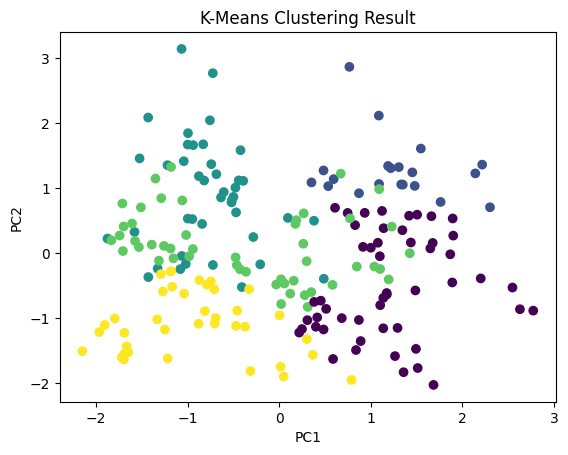


INTERPRETATION:
The graph shows the dataset divided into clusters using the K-Means algorithm.
Each color represents a different cluster of customers with similar characteristics.
Points that are close together belong to the same cluster.
This indicates that K-Means successfully groups customers based on feature similarity.

========== TASK 3 : EVALUATION METRICS ==========
Silhouette Score: 0.27191023466188324
Davies-Bouldin Index: 1.181091452406171
Calinski-Harabasz Score: 62.12634193286723
Inertia (WCSS): 351.7432061711911

INTERPRETATION:
Silhouette Score indicates how well clusters are separated (higher is better).
Davies-Bouldin Index measures similarity between clusters (lower is better).
Calinski-Harabasz Score measures cluster compactness and separation (higher is better).
WCSS shows how compact the clusters are around their centroids.

Stability Test Results
Average Silhouette: 0.2902342627618181
Variance: 0.00017401647671587368

INTERPRETATION:
Running K-Means multiple time

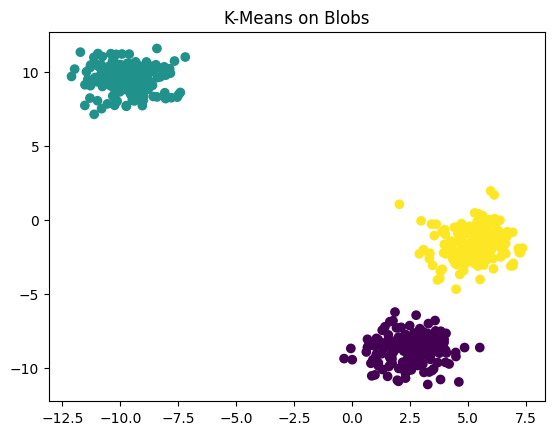


INTERPRETATION for Blobs
The clusters are spherical and well separated.
K-Means correctly identifies the clusters.
This shows that K-Means performs best on circular cluster shapes.


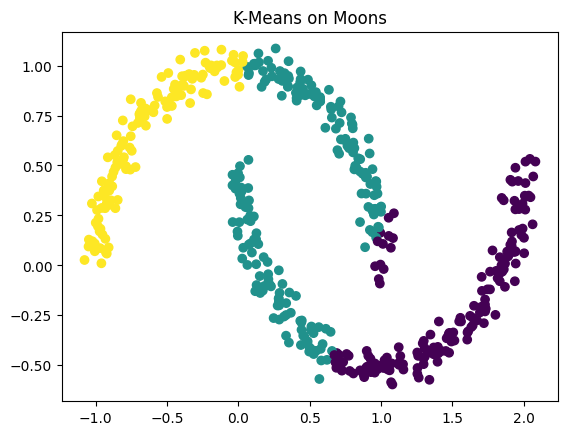


INTERPRETATION for Moons
The clusters have curved shapes.
K-Means incorrectly splits the clusters because it assumes spherical clusters.
This shows K-Means struggles with non-linear patterns.


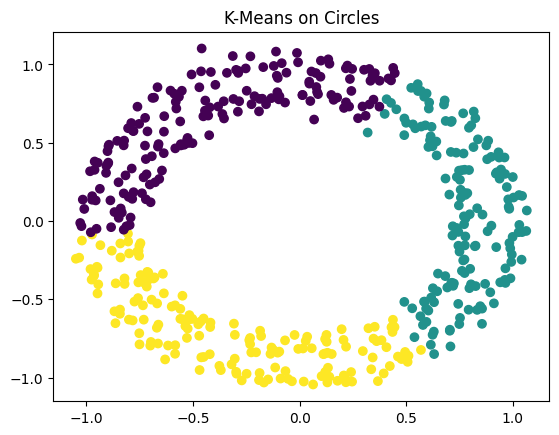


INTERPRETATION for Circles
The clusters form concentric circular patterns.
K-Means fails to separate inner and outer circles.
This shows K-Means cannot detect complex cluster shapes.

========== TASK 5 : OUTLIER TEST ==========


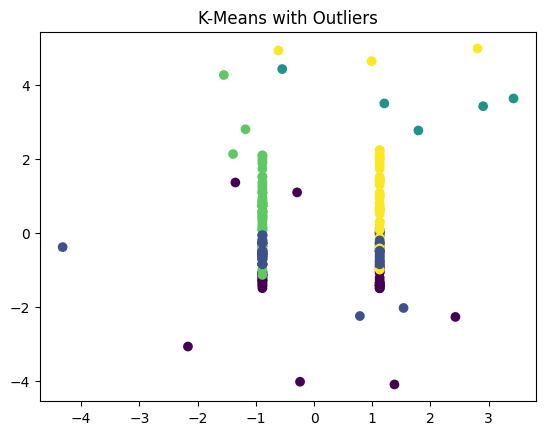


INTERPRETATION:
Random noise points were added to test robustness.
The cluster boundaries change because centroids shift toward outliers.
This shows that K-Means is sensitive to noise and extreme values.

========== TASK 6 : COMPLEXITY STUDY ==========


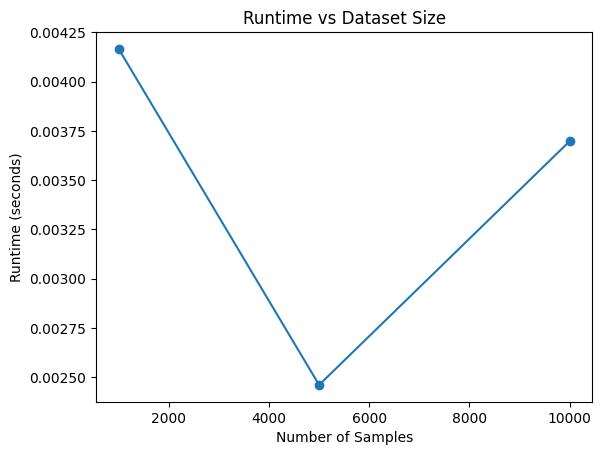


INTERPRETATION:
The graph shows how runtime increases as dataset size grows.
More samples require more distance calculations and centroid updates.
However, the increase is gradual, showing that K-Means scales relatively well for larger datasets.


In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.datasets import make_blobs, make_moons, make_circles


# =====================================================
# TASK 1 – DATA PREPARATION
# =====================================================

print("\n========== TASK 1 : DATA PREPARATION ==========")

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Remove ID column
df = df.drop("CustomerID", axis=1)

# Encode gender
df["Gender"] = df["Gender"].map({"Male":1,"Female":0})

# Handle missing values
df = df.dropna()

print("\nCleaned Dataset Preview:")
print(df.head())

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization of Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nINTERPRETATION:")
print("The PCA plot reduces the dataset into two principal components.")
print("This helps visualize high-dimensional data in 2D space.")
print("From the graph we can observe the distribution of customer data.")
print("Some natural groupings appear, suggesting clustering algorithms like K-Means can segment the data.")


# =====================================================
# TASK 2 – K-MEANS IMPLEMENTATION
# =====================================================

print("\n========== TASK 2 : K-MEANS CLUSTERING ==========")

kmeans = KMeans(n_clusters=5, random_state=42)

labels = kmeans.fit_predict(X_scaled)

print("\nCluster Centers:")
print(kmeans.cluster_centers_)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("K-Means Clustering Result")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nINTERPRETATION:")
print("The graph shows the dataset divided into clusters using the K-Means algorithm.")
print("Each color represents a different cluster of customers with similar characteristics.")
print("Points that are close together belong to the same cluster.")
print("This indicates that K-Means successfully groups customers based on feature similarity.")


# =====================================================
# TASK 3 – MATHEMATICAL EVALUATION
# =====================================================

print("\n========== TASK 3 : EVALUATION METRICS ==========")

sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", db)
print("Calinski-Harabasz Score:", ch)
print("Inertia (WCSS):", kmeans.inertia_)

print("\nINTERPRETATION:")
print("Silhouette Score indicates how well clusters are separated (higher is better).")
print("Davies-Bouldin Index measures similarity between clusters (lower is better).")
print("Calinski-Harabasz Score measures cluster compactness and separation (higher is better).")
print("WCSS shows how compact the clusters are around their centroids.")


# Stability Test

scores = []

for i in range(10):
    km = KMeans(n_clusters=5)
    lbl = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, lbl)
    scores.append(score)

print("\nStability Test Results")
print("Average Silhouette:", np.mean(scores))
print("Variance:", np.var(scores))

print("\nINTERPRETATION:")
print("Running K-Means multiple times checks algorithm stability.")
print("Low variance means clustering results are consistent across runs.")


# =====================================================
# TASK 4 – SHAPE SENSITIVITY STUDY
# =====================================================

print("\n========== TASK 4 : SHAPE SENSITIVITY ==========")

datasets = {
"Blobs": make_blobs(n_samples=500, centers=3)[0],
"Moons": make_moons(n_samples=500, noise=0.05)[0],
"Circles": make_circles(n_samples=500, noise=0.05)[0]
}

for name, data in datasets.items():

    labels = KMeans(n_clusters=3).fit_predict(data)

    plt.figure()
    plt.scatter(data[:,0], data[:,1], c=labels)
    plt.title("K-Means on " + name)
    plt.show()

    print("\nINTERPRETATION for", name)

    if name == "Blobs":
        print("The clusters are spherical and well separated.")
        print("K-Means correctly identifies the clusters.")
        print("This shows that K-Means performs best on circular cluster shapes.")

    if name == "Moons":
        print("The clusters have curved shapes.")
        print("K-Means incorrectly splits the clusters because it assumes spherical clusters.")
        print("This shows K-Means struggles with non-linear patterns.")

    if name == "Circles":
        print("The clusters form concentric circular patterns.")
        print("K-Means fails to separate inner and outer circles.")
        print("This shows K-Means cannot detect complex cluster shapes.")


# =====================================================
# TASK 5 – OUTLIER ROBUSTNESS
# =====================================================

print("\n========== TASK 5 : OUTLIER TEST ==========")

noise = np.random.uniform(-5,5,(20,X_scaled.shape[1]))

X_noisy = np.vstack([X_scaled,noise])

labels_noise = KMeans(n_clusters=5).fit_predict(X_noisy)

plt.figure()
plt.scatter(X_noisy[:,0], X_noisy[:,1], c=labels_noise)
plt.title("K-Means with Outliers")
plt.show()

print("\nINTERPRETATION:")
print("Random noise points were added to test robustness.")
print("The cluster boundaries change because centroids shift toward outliers.")
print("This shows that K-Means is sensitive to noise and extreme values.")


# =====================================================
# TASK 6 – COMPLEXITY STUDY
# =====================================================

print("\n========== TASK 6 : COMPLEXITY STUDY ==========")

sizes = [1000, 5000, 10000]

times = []

for n in sizes:

    X,_ = make_blobs(n_samples=n, centers=3)

    start = time.time()

    KMeans(n_clusters=3).fit(X)

    end = time.time()

    times.append(end-start)

plt.figure()
plt.plot(sizes, times, marker="o")
plt.xlabel("Number of Samples")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs Dataset Size")
plt.show()

print("\nINTERPRETATION:")
print("The graph shows how runtime increases as dataset size grows.")
print("More samples require more distance calculations and centroid updates.")
print("However, the increase is gradual, showing that K-Means scales relatively well for larger datasets.")


========== TASK 1 : DATA PREPARATION ==========

Cleaned Dataset Preview:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


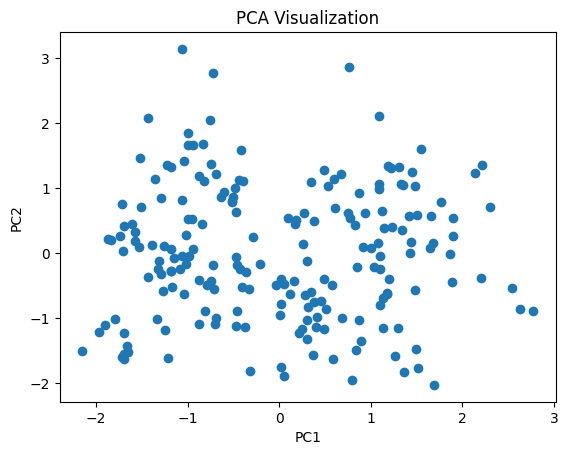


INTERPRETATION:
The PCA plot shows the distribution of customer data in two dimensions.
This helps visualize possible natural groupings before applying clustering.

========== TASK 2 : K-MEDOIDS CLUSTERING ==========

Medoid Points:
[[ 1.12815215  0.65666521 -0.25039146 -0.16305055]
 [-0.88640526 -1.13750203  0.05496398 -0.35715836]
 [-0.88640526 -0.6351352   0.66567484  1.07923939]
 [-0.88640526  0.80019859 -0.67025518 -0.20187212]
 [-0.88640526  0.36959845  0.66567484 -1.17241113]]


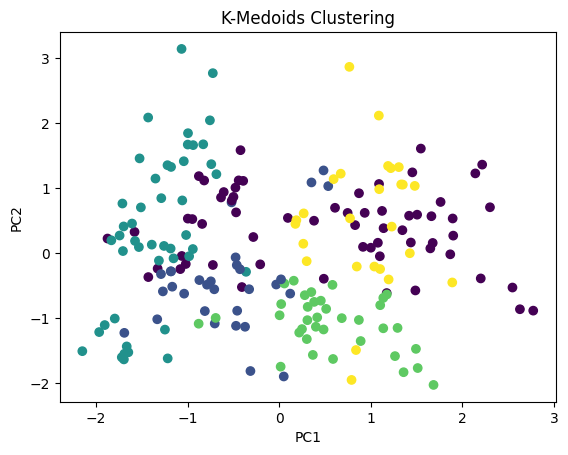


INTERPRETATION:
The dataset is divided into clusters using K-Medoids.
Each cluster is represented by a medoid (an actual data point).
This makes the algorithm more robust to outliers compared to K-Means.

========== TASK 3 : EVALUATION METRICS ==========
Silhouette Score: 0.1920266947318953
Davies-Bouldin Index: 1.3308657510456245
Calinski-Harabasz Score: 42.95502196212792

INTERPRETATION:
Silhouette Score evaluates cluster separation.
Davies-Bouldin Index measures cluster similarity.
Calinski-Harabasz Score evaluates cluster compactness.

Stability Test
Average Silhouette: 0.19202669473189532
Variance: 7.703719777548943e-34

INTERPRETATION:
Running the algorithm multiple times checks stability.
Low variance means clustering results are consistent.

========== TASK 4 : SHAPE SENSITIVITY ==========


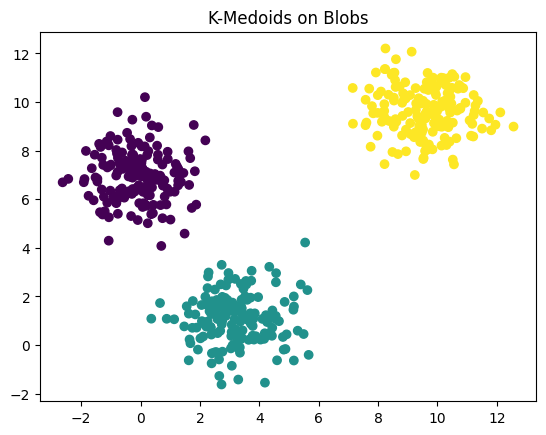


INTERPRETATION for Blobs
Clusters are spherical and well separated.
K-Medoids correctly identifies clusters similar to K-Means.


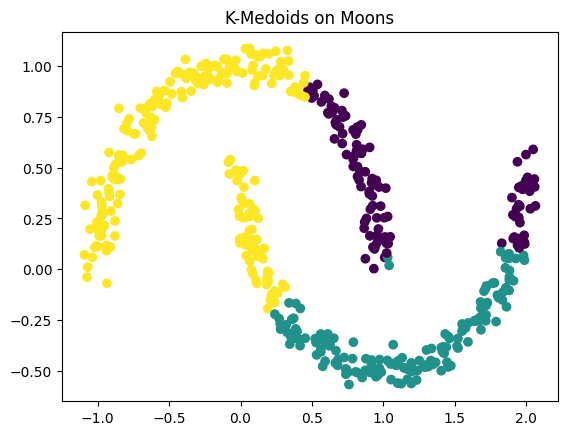


INTERPRETATION for Moons
Clusters are curved.
K-Medoids performs slightly better but still struggles with non-linear shapes.


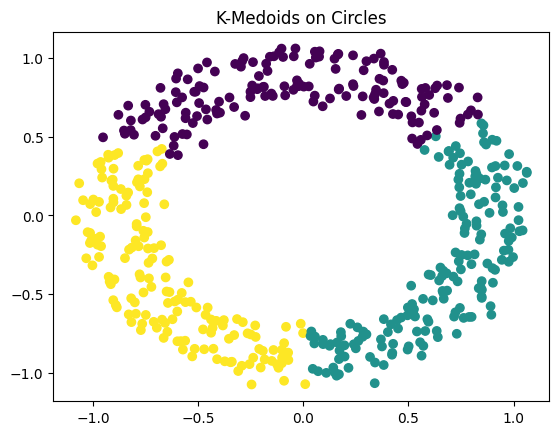


INTERPRETATION for Circles
Clusters are circular patterns.
K-Medoids cannot fully capture concentric clusters.

========== TASK 5 : OUTLIER TEST ==========


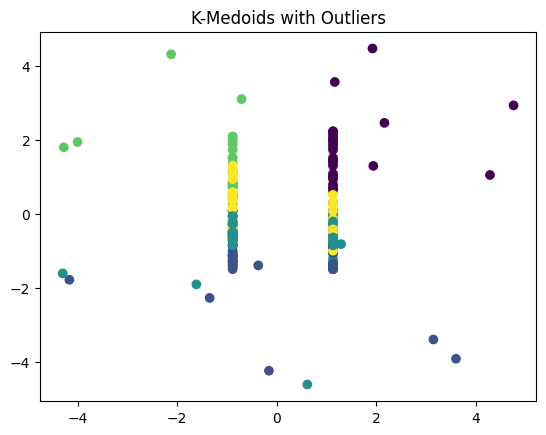


INTERPRETATION:
The clustering result changes less compared to K-Means.
Because medoids are actual data points, the algorithm is more robust to outliers.

========== TASK 6 : COMPLEXITY STUDY ==========


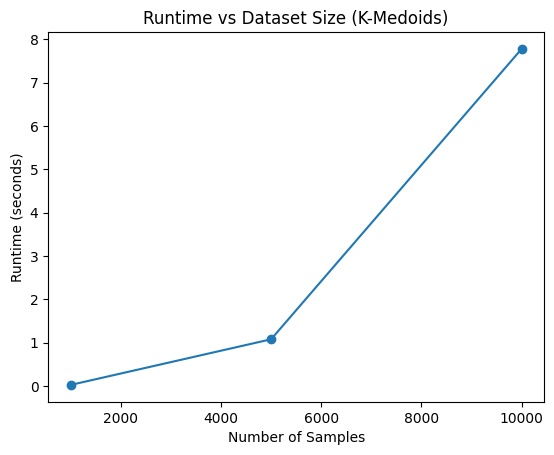


INTERPRETATION:
Runtime increases as dataset size grows.
K-Medoids is generally slower than K-Means because it evaluates many possible medoids.
However, it provides better robustness to noise and outliers.


In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.datasets import make_blobs, make_moons, make_circles

from sklearn_extra.cluster import KMedoids


# =====================================================
# TASK 1 – DATA PREPARATION
# =====================================================

print("\n========== TASK 1 : DATA PREPARATION ==========")

df = pd.read_csv("Mall_Customers.csv")

df = df.drop("CustomerID", axis=1)

df["Gender"] = df["Gender"].map({"Male":1,"Female":0})

df = df.dropna()

print("\nCleaned Dataset Preview:")
print(df.head())

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0],X_pca[:,1])
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nINTERPRETATION:")
print("The PCA plot shows the distribution of customer data in two dimensions.")
print("This helps visualize possible natural groupings before applying clustering.")


# =====================================================
# TASK 2 – K-MEDOIDS IMPLEMENTATION
# =====================================================

print("\n========== TASK 2 : K-MEDOIDS CLUSTERING ==========")

kmedoids = KMedoids(n_clusters=5, metric="manhattan", random_state=42)

labels = kmedoids.fit_predict(X_scaled)

print("\nMedoid Points:")
print(kmedoids.cluster_centers_)

plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.title("K-Medoids Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nINTERPRETATION:")
print("The dataset is divided into clusters using K-Medoids.")
print("Each cluster is represented by a medoid (an actual data point).")
print("This makes the algorithm more robust to outliers compared to K-Means.")


# =====================================================
# TASK 3 – MATHEMATICAL EVALUATION
# =====================================================

print("\n========== TASK 3 : EVALUATION METRICS ==========")

sil = silhouette_score(X_scaled,labels)
db = davies_bouldin_score(X_scaled,labels)
ch = calinski_harabasz_score(X_scaled,labels)

print("Silhouette Score:",sil)
print("Davies-Bouldin Index:",db)
print("Calinski-Harabasz Score:",ch)

print("\nINTERPRETATION:")
print("Silhouette Score evaluates cluster separation.")
print("Davies-Bouldin Index measures cluster similarity.")
print("Calinski-Harabasz Score evaluates cluster compactness.")


# Stability Test

scores = []

for i in range(10):

    km = KMedoids(n_clusters=5, metric="manhattan")

    lbl = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,lbl)

    scores.append(score)

print("\nStability Test")
print("Average Silhouette:",np.mean(scores))
print("Variance:",np.var(scores))

print("\nINTERPRETATION:")
print("Running the algorithm multiple times checks stability.")
print("Low variance means clustering results are consistent.")


# =====================================================
# TASK 4 – SHAPE SENSITIVITY STUDY
# =====================================================

print("\n========== TASK 4 : SHAPE SENSITIVITY ==========")

datasets = {
"Blobs": make_blobs(n_samples=500,centers=3)[0],
"Moons": make_moons(n_samples=500,noise=0.05)[0],
"Circles": make_circles(n_samples=500,noise=0.05)[0]
}

for name,data in datasets.items():

    labels = KMedoids(n_clusters=3, metric="manhattan").fit_predict(data)

    plt.scatter(data[:,0],data[:,1],c=labels)
    plt.title("K-Medoids on "+name)
    plt.show()

    print("\nINTERPRETATION for",name)

    if name == "Blobs":
        print("Clusters are spherical and well separated.")
        print("K-Medoids correctly identifies clusters similar to K-Means.")

    if name == "Moons":
        print("Clusters are curved.")
        print("K-Medoids performs slightly better but still struggles with non-linear shapes.")

    if name == "Circles":
        print("Clusters are circular patterns.")
        print("K-Medoids cannot fully capture concentric clusters.")


# =====================================================
# TASK 5 – OUTLIER ROBUSTNESS
# =====================================================

print("\n========== TASK 5 : OUTLIER TEST ==========")

noise = np.random.uniform(-5,5,(20,X_scaled.shape[1]))

X_noisy = np.vstack([X_scaled,noise])

labels_noise = KMedoids(n_clusters=5,metric="manhattan").fit_predict(X_noisy)

plt.scatter(X_noisy[:,0],X_noisy[:,1],c=labels_noise)
plt.title("K-Medoids with Outliers")
plt.show()

print("\nINTERPRETATION:")
print("The clustering result changes less compared to K-Means.")
print("Because medoids are actual data points, the algorithm is more robust to outliers.")


# =====================================================
# TASK 6 – COMPLEXITY STUDY
# =====================================================

print("\n========== TASK 6 : COMPLEXITY STUDY ==========")

sizes = [1000,5000,10000]

times = []

for n in sizes:

    X,_ = make_blobs(n_samples=n,centers=3)

    start = time.time()

    KMedoids(n_clusters=3).fit(X)

    end = time.time()

    times.append(end-start)

plt.plot(sizes,times,marker="o")
plt.xlabel("Number of Samples")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs Dataset Size (K-Medoids)")
plt.show()

print("\nINTERPRETATION:")
print("Runtime increases as dataset size grows.")
print("K-Medoids is generally slower than K-Means because it evaluates many possible medoids.")
print("However, it provides better robustness to noise and outliers.")


========== TASK 1 : DATA PREPARATION ==========

Cleaned Dataset Preview:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


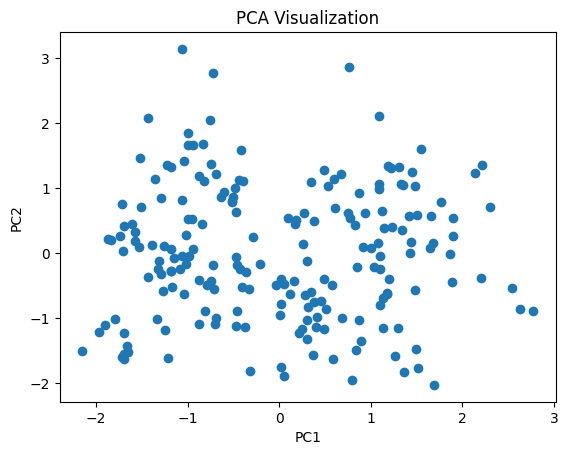


INTERPRETATION:
The PCA graph shows how the customer data is distributed.
It reduces high-dimensional data into two dimensions for visualization.

========== TASK 2 : DENDROGRAM ANALYSIS ==========


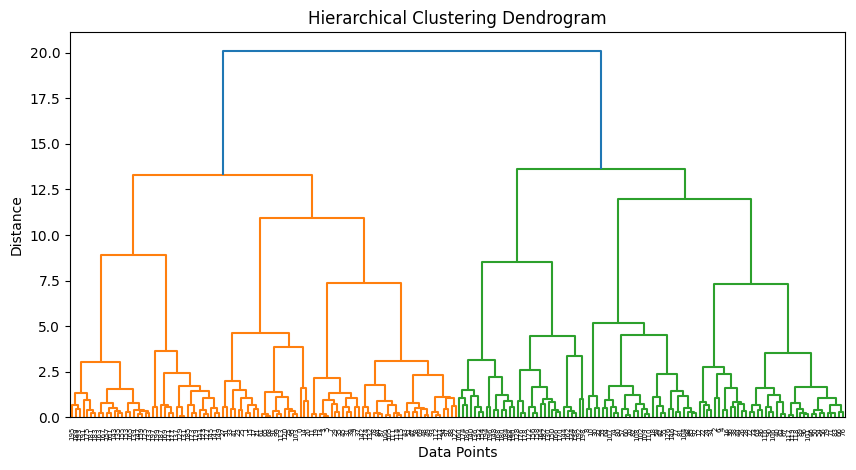


INTERPRETATION:
The dendrogram shows how clusters merge during hierarchical clustering.
Large vertical distances indicate strong separation between clusters.
Cutting the dendrogram at a certain height helps determine the number of clusters.

========== TASK 3 : AGGLOMERATIVE CLUSTERING ==========


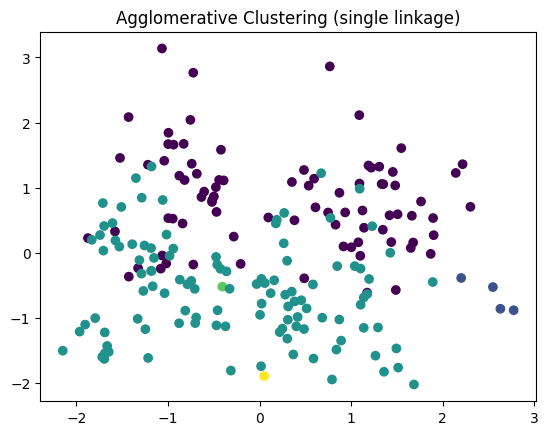


INTERPRETATION for single linkage:
Clusters are formed by merging the closest clusters step by step.
Different linkage methods change how cluster distances are measured.


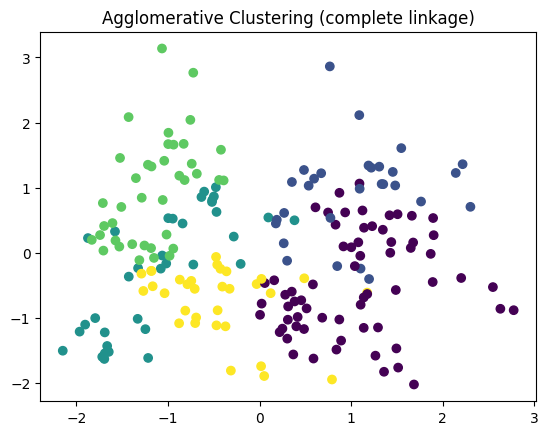


INTERPRETATION for complete linkage:
Clusters are formed by merging the closest clusters step by step.
Different linkage methods change how cluster distances are measured.


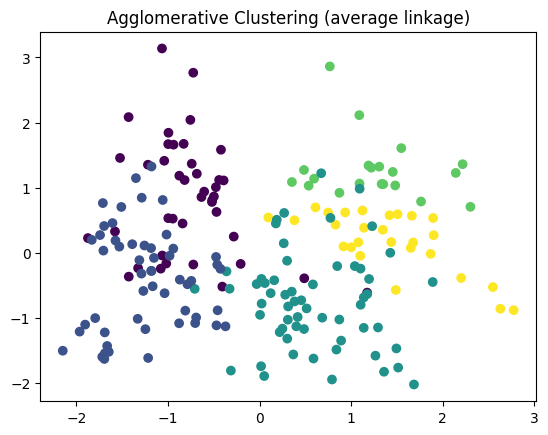


INTERPRETATION for average linkage:
Clusters are formed by merging the closest clusters step by step.
Different linkage methods change how cluster distances are measured.


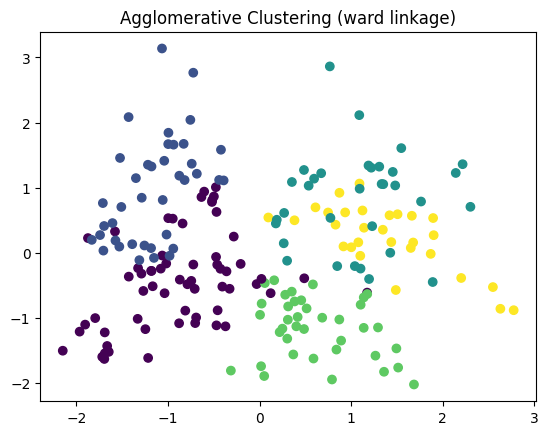


INTERPRETATION for ward linkage:
Clusters are formed by merging the closest clusters step by step.
Different linkage methods change how cluster distances are measured.

========== TASK 4 : EVALUATION METRICS ==========

Linkage: single
Silhouette Score: 0.1218252098604483
Davies-Bouldin Index: 1.0346068901953445
Calinski-Harabasz Score: 21.49014117854712

Linkage: complete
Silhouette Score: 0.243309230918067
Davies-Bouldin Index: 1.3776661029684802
Calinski-Harabasz Score: 56.8577118439795

Linkage: average
Silhouette Score: 0.3074582793074308
Davies-Bouldin Index: 1.1677734316447235
Calinski-Harabasz Score: 66.17191068128749

Linkage: ward
Silhouette Score: 0.28699413201651747
Davies-Bouldin Index: 1.2197730790225612
Calinski-Harabasz Score: 64.46870730105833

INTERPRETATION:
These metrics evaluate cluster quality.
Higher Silhouette and CH scores indicate better clustering.
Lower Davies-Bouldin values indicate better cluster separation.

========== TASK 5 : SHAPE SENSITIVITY ========

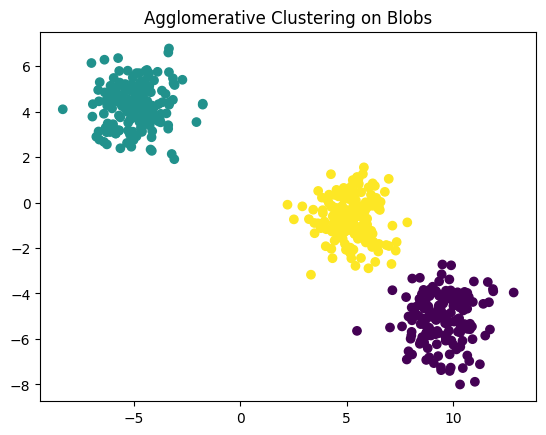


INTERPRETATION for Blobs
Clusters are spherical and clearly separated.
Agglomerative clustering identifies clusters correctly.


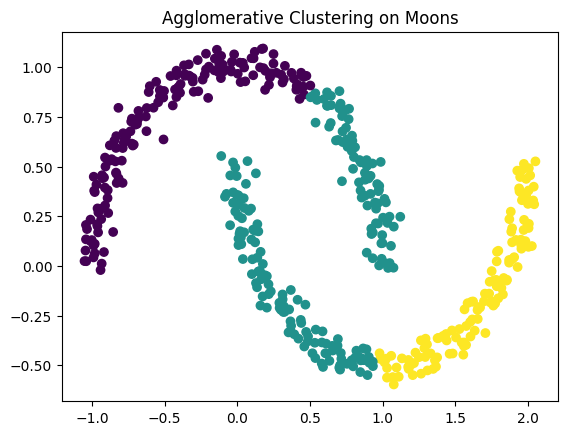


INTERPRETATION for Moons
Clusters have curved shapes.
Agglomerative clustering can handle these shapes better than K-Means.


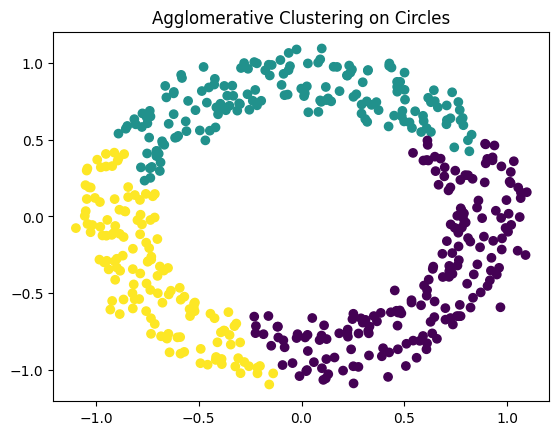


INTERPRETATION for Circles
Clusters form circular structures.
Agglomerative clustering performs better than K-Means but may still struggle with complex patterns.

========== TASK 6 : OUTLIER TEST ==========


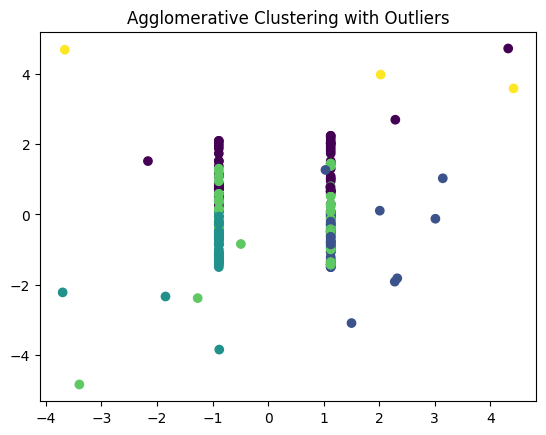


INTERPRETATION:
Outliers may affect hierarchical clustering because they can form separate clusters.
However, hierarchical clustering is often less sensitive to noise than K-Means.

========== TASK 7 : COMPLEXITY STUDY ==========


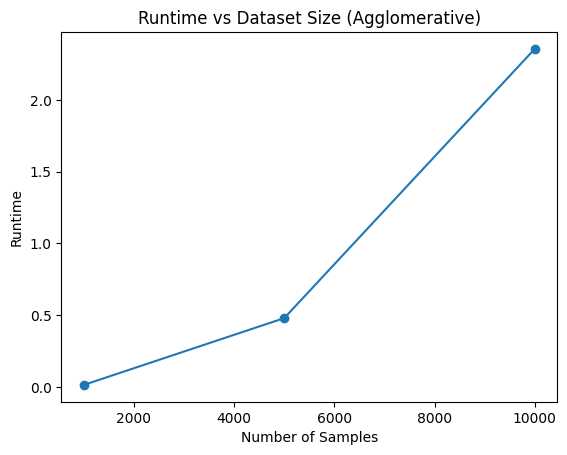


INTERPRETATION:
Runtime increases significantly as dataset size increases.
Hierarchical clustering is computationally expensive compared to K-Means.
This makes it less suitable for very large datasets.


In [2]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.datasets import make_blobs, make_moons, make_circles

from scipy.cluster.hierarchy import dendrogram, linkage


# =====================================================
# TASK 1 – DATA PREPARATION
# =====================================================

print("\n========== TASK 1 : DATA PREPARATION ==========")

df = pd.read_csv("Mall_Customers.csv")

df = df.drop("CustomerID", axis=1)

df["Gender"] = df["Gender"].map({"Male":1,"Female":0})

df = df.dropna()

print("\nCleaned Dataset Preview:")
print(df.head())

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0],X_pca[:,1])
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nINTERPRETATION:")
print("The PCA graph shows how the customer data is distributed.")
print("It reduces high-dimensional data into two dimensions for visualization.")


# =====================================================
# TASK 2 – DENDROGRAM ANALYSIS
# =====================================================

print("\n========== TASK 2 : DENDROGRAM ANALYSIS ==========")

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

print("\nINTERPRETATION:")
print("The dendrogram shows how clusters merge during hierarchical clustering.")
print("Large vertical distances indicate strong separation between clusters.")
print("Cutting the dendrogram at a certain height helps determine the number of clusters.")


# =====================================================
# TASK 3 – AGGLOMERATIVE CLUSTERING
# =====================================================

print("\n========== TASK 3 : AGGLOMERATIVE CLUSTERING ==========")

linkages = ["single","complete","average","ward"]

results = {}

for link in linkages:

    model = AgglomerativeClustering(n_clusters=5, linkage=link)

    labels = model.fit_predict(X_scaled)

    results[link] = labels

    plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
    plt.title("Agglomerative Clustering ("+link+" linkage)")
    plt.show()

    print("\nINTERPRETATION for",link,"linkage:")
    print("Clusters are formed by merging the closest clusters step by step.")
    print("Different linkage methods change how cluster distances are measured.")


# =====================================================
# TASK 4 – MATHEMATICAL EVALUATION
# =====================================================

print("\n========== TASK 4 : EVALUATION METRICS ==========")

for name,labels in results.items():

    sil = silhouette_score(X_scaled,labels)
    db = davies_bouldin_score(X_scaled,labels)
    ch = calinski_harabasz_score(X_scaled,labels)

    print("\nLinkage:",name)
    print("Silhouette Score:",sil)
    print("Davies-Bouldin Index:",db)
    print("Calinski-Harabasz Score:",ch)

print("\nINTERPRETATION:")
print("These metrics evaluate cluster quality.")
print("Higher Silhouette and CH scores indicate better clustering.")
print("Lower Davies-Bouldin values indicate better cluster separation.")


# =====================================================
# TASK 5 – SHAPE SENSITIVITY STUDY
# =====================================================

print("\n========== TASK 5 : SHAPE SENSITIVITY ==========")

datasets = {
"Blobs": make_blobs(n_samples=500,centers=3)[0],
"Moons": make_moons(n_samples=500,noise=0.05)[0],
"Circles": make_circles(n_samples=500,noise=0.05)[0]
}

for name,data in datasets.items():

    labels = AgglomerativeClustering(n_clusters=3).fit_predict(data)

    plt.scatter(data[:,0],data[:,1],c=labels)
    plt.title("Agglomerative Clustering on "+name)
    plt.show()

    print("\nINTERPRETATION for",name)

    if name == "Blobs":
        print("Clusters are spherical and clearly separated.")
        print("Agglomerative clustering identifies clusters correctly.")

    if name == "Moons":
        print("Clusters have curved shapes.")
        print("Agglomerative clustering can handle these shapes better than K-Means.")

    if name == "Circles":
        print("Clusters form circular structures.")
        print("Agglomerative clustering performs better than K-Means but may still struggle with complex patterns.")


# =====================================================
# TASK 6 – OUTLIER ROBUSTNESS
# =====================================================

print("\n========== TASK 6 : OUTLIER TEST ==========")

noise = np.random.uniform(-5,5,(20,X_scaled.shape[1]))

X_noisy = np.vstack([X_scaled,noise])

labels = AgglomerativeClustering(n_clusters=5).fit_predict(X_noisy)

plt.scatter(X_noisy[:,0],X_noisy[:,1],c=labels)
plt.title("Agglomerative Clustering with Outliers")
plt.show()

print("\nINTERPRETATION:")
print("Outliers may affect hierarchical clustering because they can form separate clusters.")
print("However, hierarchical clustering is often less sensitive to noise than K-Means.")


# =====================================================
# TASK 7 – COMPLEXITY STUDY
# =====================================================

print("\n========== TASK 7 : COMPLEXITY STUDY ==========")

sizes = [1000,5000,10000]

times = []

for n in sizes:

    X,_ = make_blobs(n_samples=n,centers=3)

    start = time.time()

    AgglomerativeClustering(n_clusters=3).fit(X)

    end = time.time()

    times.append(end-start)

plt.plot(sizes,times,marker="o")
plt.xlabel("Number of Samples")
plt.ylabel("Runtime")
plt.title("Runtime vs Dataset Size (Agglomerative)")
plt.show()

print("\nINTERPRETATION:")
print("Runtime increases significantly as dataset size increases.")
print("Hierarchical clustering is computationally expensive compared to K-Means.")
print("This makes it less suitable for very large datasets.")


========== TASK 1 : DATA PREPARATION ==========

Cleaned Dataset Preview:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


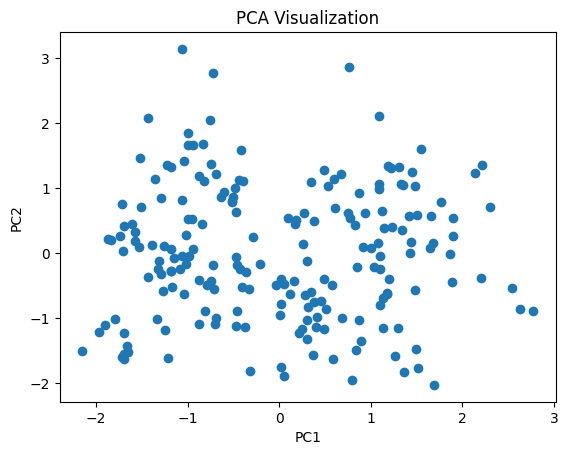


INTERPRETATION:
The PCA plot visualizes the dataset in two dimensions.
It helps observe possible patterns and cluster structures before applying clustering.

========== TASK 2 : GMM CLUSTERING ==========

Cluster Probabilities (first 5 rows):
[[0.00000000e+00 2.30689831e-03 9.97693102e-01 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 2.18718568e-06 9.99997813e-01 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.98654807e-02
  9.80134519e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 3.00596850e-03
  9.96994031e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 3.00468895e-02
  9.69953111e-01]]


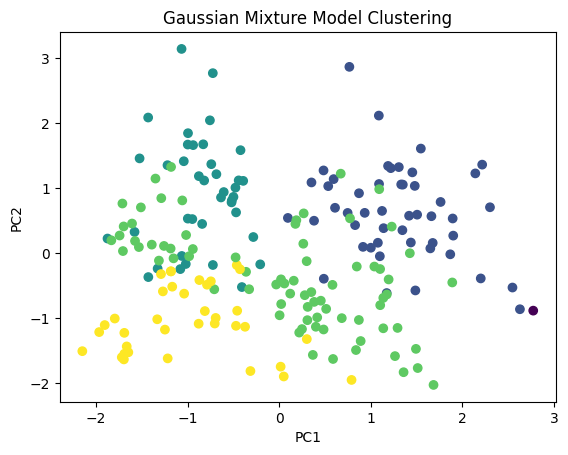


INTERPRETATION:
Each color represents a cluster detected by the GMM.
Unlike K-Means, GMM assigns probabilities for belonging to each cluster.
This allows soft clustering where points can belong partially to multiple clusters.

========== TASK 3 : EVALUATION METRICS ==========
Silhouette Score: 0.22164014854021982
Davies-Bouldin Index: 1.210613767104373
Calinski-Harabasz Score: 45.81743407409342

INTERPRETATION:
Silhouette Score measures how well clusters are separated.
Davies-Bouldin Index measures cluster similarity (lower is better).
Calinski-Harabasz Score evaluates cluster compactness.

Stability Test
Average Silhouette: 0.22296471604835216
Variance: 0.00364673250390853

INTERPRETATION:
Running GMM multiple times checks algorithm stability.
Low variance indicates consistent clustering results.

========== TASK 4 : SHAPE SENSITIVITY ==========


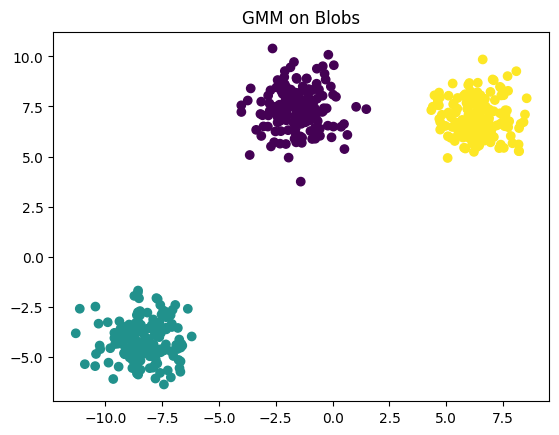


INTERPRETATION for Blobs
Clusters are spherical and well separated.
GMM successfully detects clusters similar to K-Means.


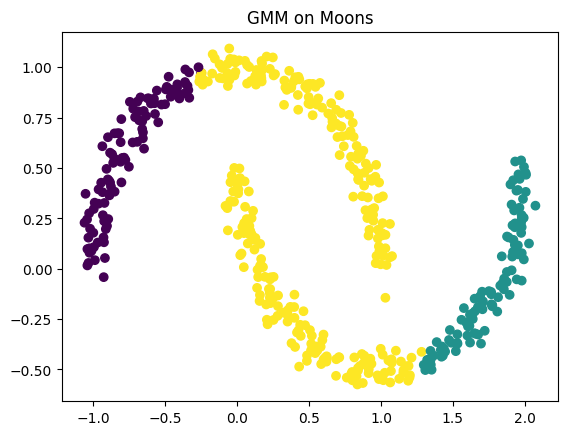


INTERPRETATION for Moons
Clusters are curved.
GMM performs better than K-Means but may still struggle with complex shapes.


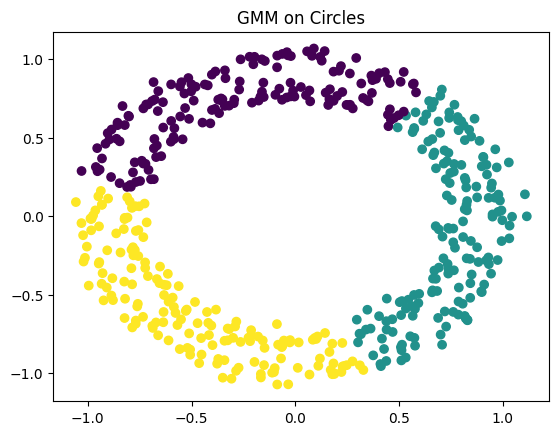


INTERPRETATION for Circles
Clusters form circular patterns.
GMM performs better than K-Means because it models probabilistic distributions.

========== TASK 5 : OUTLIER TEST ==========


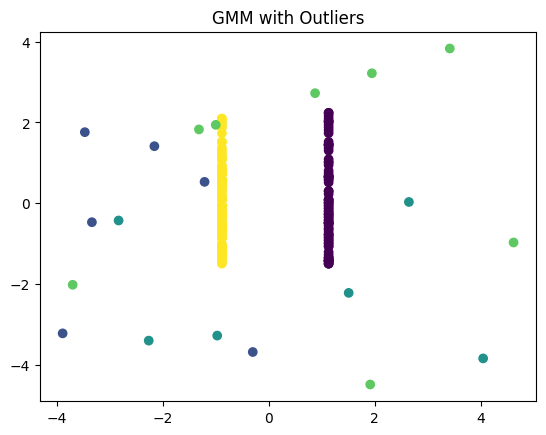


INTERPRETATION:
GMM is less sensitive to outliers compared to K-Means.
Because it models clusters probabilistically, noise has a smaller effect.

========== TASK 6 : COMPLEXITY STUDY ==========


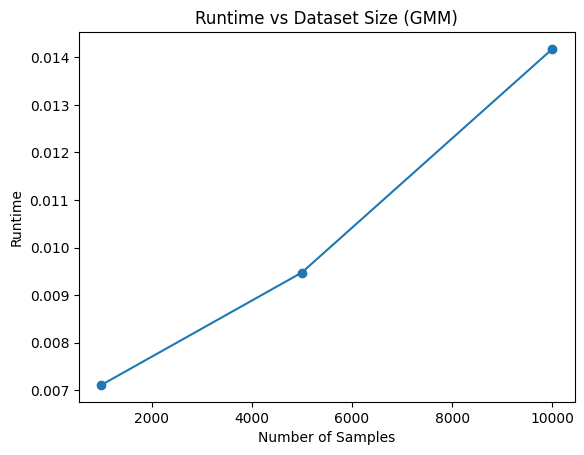


INTERPRETATION:
Runtime increases as dataset size increases.
GMM requires multiple iterations to estimate probability distributions.
Therefore it is generally slower than K-Means but provides more flexible clustering.


In [3]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.datasets import make_blobs, make_moons, make_circles


# =====================================================
# TASK 1 – DATA PREPARATION
# =====================================================

print("\n========== TASK 1 : DATA PREPARATION ==========")

df = pd.read_csv("Mall_Customers.csv")

df = df.drop("CustomerID", axis=1)

df["Gender"] = df["Gender"].map({"Male":1,"Female":0})

df = df.dropna()

print("\nCleaned Dataset Preview:")
print(df.head())

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nINTERPRETATION:")
print("The PCA plot visualizes the dataset in two dimensions.")
print("It helps observe possible patterns and cluster structures before applying clustering.")


# =====================================================
# TASK 2 – GMM CLUSTERING
# =====================================================

print("\n========== TASK 2 : GMM CLUSTERING ==========")

gmm = GaussianMixture(n_components=5, random_state=42)

labels = gmm.fit_predict(X_scaled)

probabilities = gmm.predict_proba(X_scaled)

print("\nCluster Probabilities (first 5 rows):")
print(probabilities[:5])

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nINTERPRETATION:")
print("Each color represents a cluster detected by the GMM.")
print("Unlike K-Means, GMM assigns probabilities for belonging to each cluster.")
print("This allows soft clustering where points can belong partially to multiple clusters.")


# =====================================================
# TASK 3 – MATHEMATICAL EVALUATION
# =====================================================

print("\n========== TASK 3 : EVALUATION METRICS ==========")

sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", db)
print("Calinski-Harabasz Score:", ch)

print("\nINTERPRETATION:")
print("Silhouette Score measures how well clusters are separated.")
print("Davies-Bouldin Index measures cluster similarity (lower is better).")
print("Calinski-Harabasz Score evaluates cluster compactness.")


# Stability Test

scores = []

for i in range(10):

    gmm = GaussianMixture(n_components=5)

    labels = gmm.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

print("\nStability Test")
print("Average Silhouette:", np.mean(scores))
print("Variance:", np.var(scores))

print("\nINTERPRETATION:")
print("Running GMM multiple times checks algorithm stability.")
print("Low variance indicates consistent clustering results.")


# =====================================================
# TASK 4 – SHAPE SENSITIVITY STUDY
# =====================================================

print("\n========== TASK 4 : SHAPE SENSITIVITY ==========")

datasets = {
"Blobs": make_blobs(n_samples=500, centers=3)[0],
"Moons": make_moons(n_samples=500, noise=0.05)[0],
"Circles": make_circles(n_samples=500, noise=0.05)[0]
}

for name, data in datasets.items():

    labels = GaussianMixture(n_components=3).fit_predict(data)

    plt.scatter(data[:,0], data[:,1], c=labels)
    plt.title("GMM on " + name)
    plt.show()

    print("\nINTERPRETATION for", name)

    if name == "Blobs":
        print("Clusters are spherical and well separated.")
        print("GMM successfully detects clusters similar to K-Means.")

    if name == "Moons":
        print("Clusters are curved.")
        print("GMM performs better than K-Means but may still struggle with complex shapes.")

    if name == "Circles":
        print("Clusters form circular patterns.")
        print("GMM performs better than K-Means because it models probabilistic distributions.")


# =====================================================
# TASK 5 – OUTLIER ROBUSTNESS
# =====================================================

print("\n========== TASK 5 : OUTLIER TEST ==========")

noise = np.random.uniform(-5,5,(20,X_scaled.shape[1]))

X_noisy = np.vstack([X_scaled, noise])

labels = GaussianMixture(n_components=5).fit_predict(X_noisy)

plt.scatter(X_noisy[:,0], X_noisy[:,1], c=labels)
plt.title("GMM with Outliers")
plt.show()

print("\nINTERPRETATION:")
print("GMM is less sensitive to outliers compared to K-Means.")
print("Because it models clusters probabilistically, noise has a smaller effect.")


# =====================================================
# TASK 6 – COMPLEXITY STUDY
# =====================================================

print("\n========== TASK 6 : COMPLEXITY STUDY ==========")

sizes = [1000,5000,10000]

times = []

for n in sizes:

    X,_ = make_blobs(n_samples=n, centers=3)

    start = time.time()

    GaussianMixture(n_components=3).fit(X)

    end = time.time()

    times.append(end-start)

plt.plot(sizes, times, marker="o")
plt.xlabel("Number of Samples")
plt.ylabel("Runtime")
plt.title("Runtime vs Dataset Size (GMM)")
plt.show()

print("\nINTERPRETATION:")
print("Runtime increases as dataset size increases.")
print("GMM requires multiple iterations to estimate probability distributions.")
print("Therefore it is generally slower than K-Means but provides more flexible clustering.")